# Notebook 03: U-Net Model Evaluation

This notebook evaluates the trained U-Net segmentation model on the held-out validation split.

The evaluation has four purposes:

1. Calculate quantitative segmentation metrics using a fixed 0.5 prediction threshold.
2. Report mean per-image Dice, IoU, Precision, and Recall.
3. Visualise representative predictions against the ground-truth masks.
4. Identify the lowest-performing validation images to support error analysis.

The trained checkpoint is loaded from the project `models` directory. No model retraining is performed in this notebook.

The evaluation uses the same dataset structure and preprocessing as the training notebook so that the reported metrics are directly comparable with the training results.

In [1]:
# ============================================================
# 1. Imports, paths and reproducibility
# ============================================================

import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

BASE_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3"

DATASET_DIR = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "nuclei_dataset"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

OUTPUT_FIG_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "figures"
)

OUTPUT_DATA_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "data"
)


# ------------------------------------------------------------
# Create output directories if required
# ------------------------------------------------------------

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)


# ------------------------------------------------------------
# Model checkpoint
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_unet_nuclei.pth"
)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Evaluation device:", device)
print("Dataset directory:", DATASET_DIR)
print("Model checkpoint:", MODEL_PATH)

Evaluation device: cpu
Dataset directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset
Model checkpoint: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\models\best_unet_nuclei.pth


## 2. Dataset structure and evaluation setup

The validation split contains paired RGB microscopy images and binary ground-truth masks.

Images are resized to 256×256 pixels using bilinear interpolation. Masks use nearest-neighbour interpolation so that binary class labels are not artificially smoothed.

The model output is converted to probabilities using a sigmoid function and then thresholded at 0.5 to obtain the final binary segmentation.

In [2]:
# ============================================================
# 2. Validation dataset
# ============================================================

class NucleiEvalDataset(Dataset):
    """
    Dataset used for deterministic validation evaluation.

    Each image is paired with its corresponding binary mask.
    Images are converted to RGB and masks to grayscale.
    """

    def __init__(
        self,
        root_dir,
        split="val",
        target_size=(256, 256)
    ):

        self.root_dir = root_dir
        self.split = split
        self.target_size = target_size

        self.img_dir = os.path.join(
            root_dir,
            split,
            "images"
        )

        self.mask_dir = os.path.join(
            root_dir,
            split,
            "masks"
        )

        self.img_files = sorted(
            glob.glob(
                os.path.join(
                    self.img_dir,
                    "*.png"
                )
            )
        )

        self.mask_files = sorted(
            glob.glob(
                os.path.join(
                    self.mask_dir,
                    "*.png"
                )
            )
        )

        if len(self.img_files) == 0:
            raise FileNotFoundError(
                f"No validation images found in: {self.img_dir}"
            )

        if len(self.mask_files) == 0:
            raise FileNotFoundError(
                f"No validation masks found in: {self.mask_dir}"
            )

        if len(self.img_files) != len(self.mask_files):
            raise ValueError(
                "Number of images and masks does not match."
            )

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):

        # Load image and mask
        img = Image.open(
            self.img_files[idx]
        ).convert("RGB")

        mask = Image.open(
            self.mask_files[idx]
        ).convert("L")

        # Resize using appropriate interpolation
        img = img.resize(
            self.target_size,
            Image.BILINEAR
        )

        mask = mask.resize(
            self.target_size,
            Image.NEAREST
        )

        # Convert to arrays
        img_arr = (
            np.asarray(
                img,
                dtype=np.float32
            ) / 255.0
        )

        mask_arr = (
            np.asarray(
                mask,
                dtype=np.float32
            ) / 255.0
        )

        # Ensure binary mask
        mask_arr = (
            mask_arr >= 0.5
        ).astype(np.float32)

        # Convert image HWC -> CHW
        image_tensor = torch.from_numpy(
            img_arr
        ).permute(2, 0, 1)

        mask_tensor = torch.from_numpy(
            mask_arr
        ).unsqueeze(0)

        return (
            image_tensor,
            mask_tensor
        )


# ------------------------------------------------------------
# Create validation dataset and loader
# ------------------------------------------------------------

val_dataset = NucleiEvalDataset(
    DATASET_DIR,
    split="val",
    target_size=(256, 256)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print(
    f"Validation images: {len(val_dataset)}"
)

Validation images: 20


In [8]:
# ============================================================
# 3. U-Net architecture
# ============================================================

class DoubleConv(nn.Module):
    """
    Two convolutional layers with batch normalisation
    and ReLU activation.

    IMPORTANT:
    The attribute is named `block` because this matches
    the parameter names stored in the trained checkpoint.
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.block(x)


class UNet(nn.Module):
    """
    Small U-Net used for nuclei segmentation.

    This architecture is deliberately kept compatible with
    the trained best_unet_nuclei.pth checkpoint.
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=(64, 128, 256, 512)
    ):

        super(UNet, self).__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        for feature in features:

            self.downs.append(
                DoubleConv(
                    in_channels,
                    feature
                )
            )

            in_channels = feature


        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            features[-1],
            features[-1] * 2
        )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        for feature in reversed(features):

            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2
                )
            )

            self.ups.append(
                DoubleConv(
                    feature * 2,
                    feature
                )
            )


        # ----------------------------------------------------
        # Final segmentation layer
        # ----------------------------------------------------

        self.final_conv = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )


    def forward(self, x):

        skip_connections = []

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        for down in self.downs:

            x = down(x)

            skip_connections.append(x)

            x = self.pool(x)


        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        x = self.bottleneck(x)


        # Reverse skip connections
        skip_connections = skip_connections[::-1]


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        for idx in range(
            0,
            len(self.ups),
            2
        ):

            x = self.ups[idx](x)

            skip_connection = (
                skip_connections[idx // 2]
            )

            x = torch.cat(
                [
                    skip_connection,
                    x
                ],
                dim=1
            )

            x = self.ups[idx + 1](x)


        return self.final_conv(x)

In [9]:
# ============================================================
# 4. Load trained checkpoint
# ============================================================

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"Trained model checkpoint not found:\n{MODEL_PATH}"
    )


model = UNet(
    in_channels=3,
    out_channels=1
).to(device)


# Load checkpoint
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)


# Support either a raw state_dict or a checkpoint dictionary
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(
        checkpoint
    )


model.eval()


print("Trained U-Net loaded successfully.")
print("Checkpoint:", MODEL_PATH)

Trained U-Net loaded successfully.
Checkpoint: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\models\best_unet_nuclei.pth


## 3. Quantitative segmentation evaluation

Four metrics are calculated for each validation image:

- **Dice coefficient** — measures overlap between prediction and ground truth.
- **IoU (Jaccard index)** — measures intersection relative to the union.
- **Precision** — measures how much predicted foreground corresponds to true foreground.
- **Recall** — measures how much of the true foreground is recovered.

Metrics are calculated separately for every validation image and then averaged. This avoids allowing a small number of large images to dominate the reported mean.

In [18]:
# ============================================================
# 6. Evaluate every validation image
# ============================================================

# Fixed threshold used for converting probabilities to
# binary segmentation masks.
THRESHOLD = 0.5

per_image_results = []

model.eval()

with torch.no_grad():

    for idx in range(len(val_dataset)):

        image, mask = val_dataset[idx]

        image_batch = (
            image
            .unsqueeze(0)
            .to(device)
        )

        # Model prediction
        logits = model(image_batch)

        probabilities = torch.sigmoid(logits)

        # Convert probabilities to binary mask
        prediction = (
            probabilities >= THRESHOLD
        ).float()

        # Convert prediction and ground truth to NumPy
        prediction_np = (
            prediction
            .squeeze()
            .cpu()
            .numpy()
        )

        mask_np = (
            mask
            .squeeze()
            .numpy()
        )

        # Calculate metrics
        metrics = calculate_binary_metrics(
            prediction_np,
            mask_np
        )

        per_image_results.append({
            "image_index": idx,
            "dice": metrics["dice"],
            "iou": metrics["iou"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "tp": metrics["tp"],
            "fp": metrics["fp"],
            "fn": metrics["fn"]
        })


# Convert all results into a DataFrame
metrics_df = pd.DataFrame(
    per_image_results
)


print(
    f"Evaluated {len(metrics_df)} validation images."
)

print(
    f"Prediction threshold: {THRESHOLD}"
)

display(metrics_df)

Evaluated 20 validation images.
Prediction threshold: 0.5


,image_index,dice,iou,precision,recall,tp,fp,fn
0,0,0.996880,0.993779,0.993779,1.000000,639,4,0
1,1,0.990832,0.981830,0.983574,0.998198,4431,74,8
2,2,0.997854,0.995717,0.997141,0.998568,2790,8,4
3,3,0.995210,0.990466,0.991484,0.998964,6753,58,7
4,4,0.995337,0.990717,0.994652,0.996022,13020,70,52
5,5,0.995636,0.991309,0.995781,0.995491,6844,29,31
6,6,0.993174,0.986441,0.988115,0.998285,1746,21,3
7,7,0.996676,0.993375,0.995509,0.997847,5098,23,11
8,8,0.996871,0.993761,0.994513,0.999240,5256,29,4
9,9,0.994347,0.988757,0.989392,0.999351,3078,33,2


In [19]:
# ============================================================
# 7. Overall validation metrics
# ============================================================

mean_dice = metrics_df["dice"].mean()
mean_iou = metrics_df["iou"].mean()
mean_precision = metrics_df["precision"].mean()
mean_recall = metrics_df["recall"].mean()


overall_metrics = pd.DataFrame({
    "Metric": [
        "Mean Dice",
        "Mean IoU",
        "Mean Precision",
        "Mean Recall"
    ],

    "Validation Score": [
        mean_dice,
        mean_iou,
        mean_precision,
        mean_recall
    ]
})


print("=" * 60)
print("FINAL VALIDATION RESULTS")
print("=" * 60)

print(
    f"Mean Dice       : {mean_dice:.4f}"
)

print(
    f"Mean IoU        : {mean_iou:.4f}"
)

print(
    f"Mean Precision  : {mean_precision:.4f}"
)

print(
    f"Mean Recall     : {mean_recall:.4f}"
)

print("=" * 60)


display(
    overall_metrics
)

FINAL VALIDATION RESULTS
Mean Dice       : 0.9948
Mean IoU        : 0.9897
Mean Precision  : 0.9915
Mean Recall     : 0.9982


,Metric,Validation Score
0,Mean Dice,0.994816
1,Mean IoU,0.989696
2,Mean Precision,0.991459
3,Mean Recall,0.998213


In [20]:
# ============================================================
# 8. Save evaluation metrics
# ============================================================

metrics_csv_path = os.path.join(
    OUTPUT_DATA_DIR,
    "unet_validation_metrics.csv"
)

metrics_df.to_csv(
    metrics_csv_path,
    index=False
)


summary_csv_path = os.path.join(
    OUTPUT_DATA_DIR,
    "unet_validation_summary.csv"
)

overall_metrics.to_csv(
    summary_csv_path,
    index=False
)


print(
    "Per-image metrics saved to:"
)

print(metrics_csv_path)

print(
    "\nSummary metrics saved to:"
)

print(summary_csv_path)

Per-image metrics saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\data\unet_validation_metrics.csv

Summary metrics saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\data\unet_validation_summary.csv


## 4. Representative qualitative predictions

Numerical metrics provide an overall measure of segmentation quality, but they do not show where errors occur.

Three validation images are therefore visualised using:

1. Original input image
2. Ground-truth segmentation
3. U-Net probability map
4. Binary U-Net prediction

The visual comparison provides evidence for whether high numerical scores correspond to visually accurate segmentation.

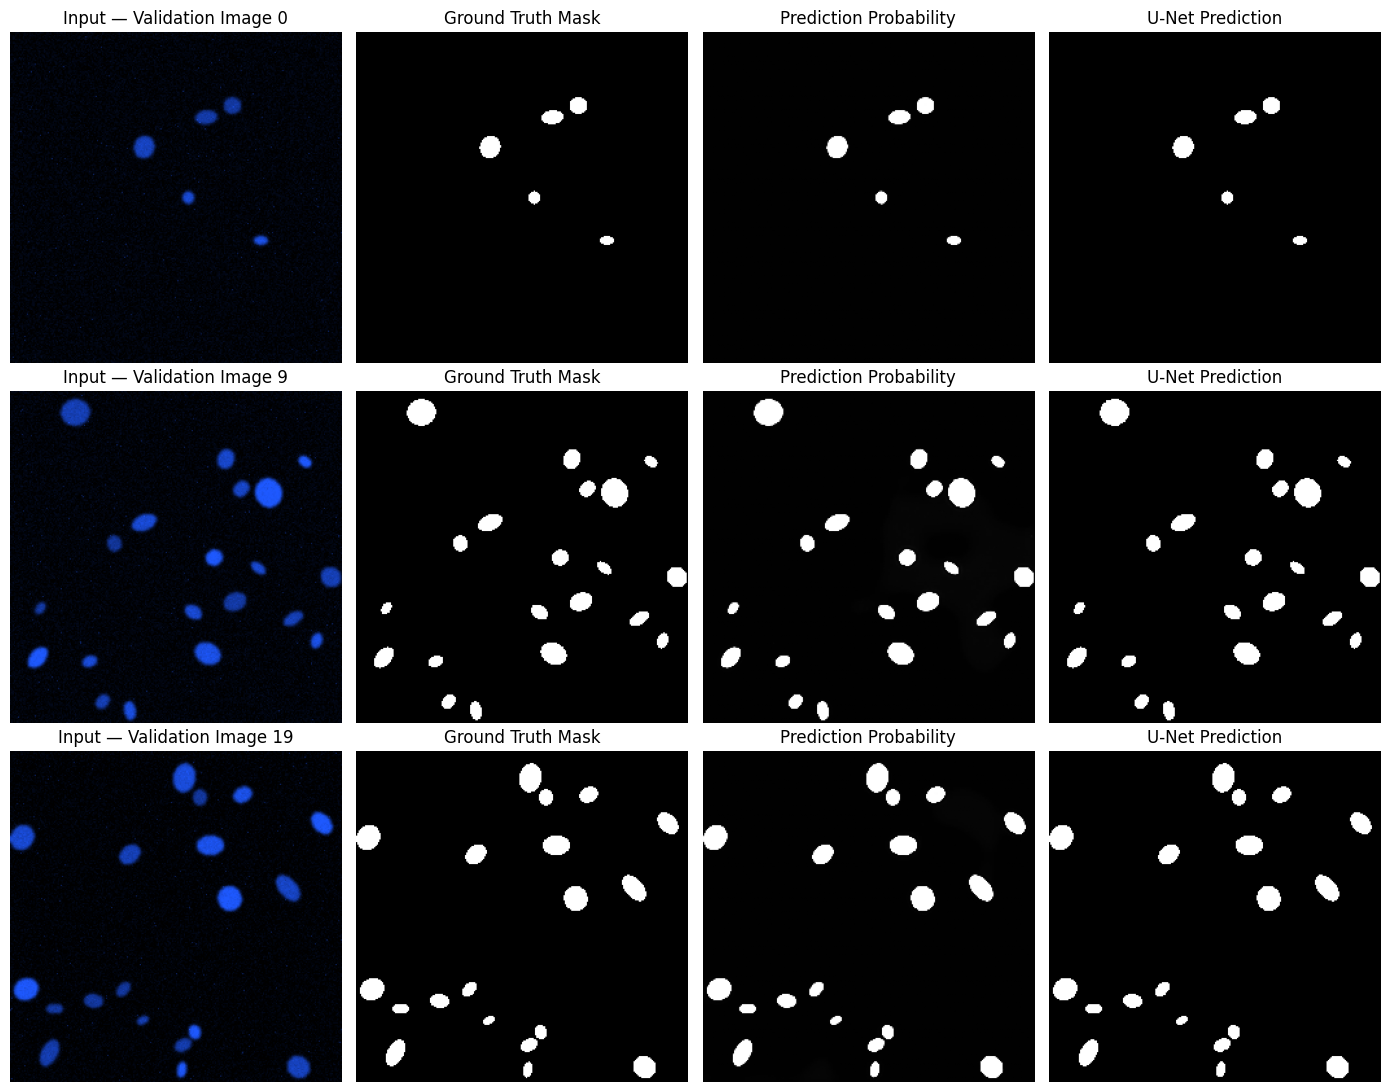

Representative evaluation figure saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_evaluation_representative.png


In [21]:
# ============================================================
# 9. Representative validation predictions
# ============================================================

def get_prediction(
    model,
    image_tensor,
    device,
    threshold=0.5
):
    """
    Generate a binary segmentation prediction
    for one image.
    """

    model.eval()

    with torch.no_grad():

        logits = model(
            image_tensor
            .unsqueeze(0)
            .to(device)
        )

        probability = torch.sigmoid(
            logits
        )

        prediction = (
            probability >= threshold
        ).float()

    return (
        probability
        .squeeze()
        .cpu()
        .numpy()
    ), (
        prediction
        .squeeze()
        .cpu()
        .numpy()
    )


# Select three representative validation images
sample_indices = [
    0,
    min(9, len(val_dataset) - 1),
    min(19, len(val_dataset) - 1)
]


fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(14, 11)
)


for row, idx in enumerate(
    sample_indices
):

    image, mask = val_dataset[idx]

    probability, prediction = get_prediction(
        model,
        image,
        device,
        THRESHOLD
    )

    image_np = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    mask_np = (
        mask
        .squeeze()
        .numpy()
    )


    # Input
    axes[row, 0].imshow(
        image_np
    )

    axes[row, 0].set_title(
        f"Input — Validation Image {idx}"
    )

    axes[row, 0].axis("off")


    # Ground truth
    axes[row, 1].imshow(
        mask_np,
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Ground Truth Mask"
    )

    axes[row, 1].axis("off")


    # Probability
    axes[row, 2].imshow(
        probability,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row, 2].set_title(
        "Prediction Probability"
    )

    axes[row, 2].axis("off")


    # Binary prediction
    axes[row, 3].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 3].set_title(
        "U-Net Prediction"
    )

    axes[row, 3].axis("off")


plt.tight_layout()


representative_path = os.path.join(
    OUTPUT_FIG_DIR,
    "unet_evaluation_representative.png"
)


plt.savefig(
    representative_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Representative evaluation figure saved to:"
)

print(representative_path)

## 5. Per-image error analysis

The mean metrics can conceal individual difficult cases. To identify where the model performs less accurately, validation images are ranked by Dice score.

The three lowest-Dice examples are then visualised.

This analysis is important because segmentation errors may be concentrated around small objects, touching objects, irregular boundaries, or objects close to image borders even when the overall mean performance is very high.

In [22]:
# ============================================================
# 10. Identify lowest-performing validation images
# ============================================================

worst_cases = (
    metrics_df
    .sort_values(
        by="dice",
        ascending=True
    )
    .head(5)
    .copy()
)


print(
    "Five lowest-performing validation images"
)

print("=" * 75)

display(
    worst_cases[
        [
            "image_index",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ]
)

Five lowest-performing validation images


,image_index,dice,iou,precision,recall
12,12,0.989063,0.978362,0.979876,0.998423
1,1,0.990832,0.981830,0.983574,0.998198
18,18,0.992204,0.984528,0.984528,1.000000
15,15,0.992296,0.984711,0.984901,0.999803
6,6,0.993174,0.986441,0.988115,0.998285


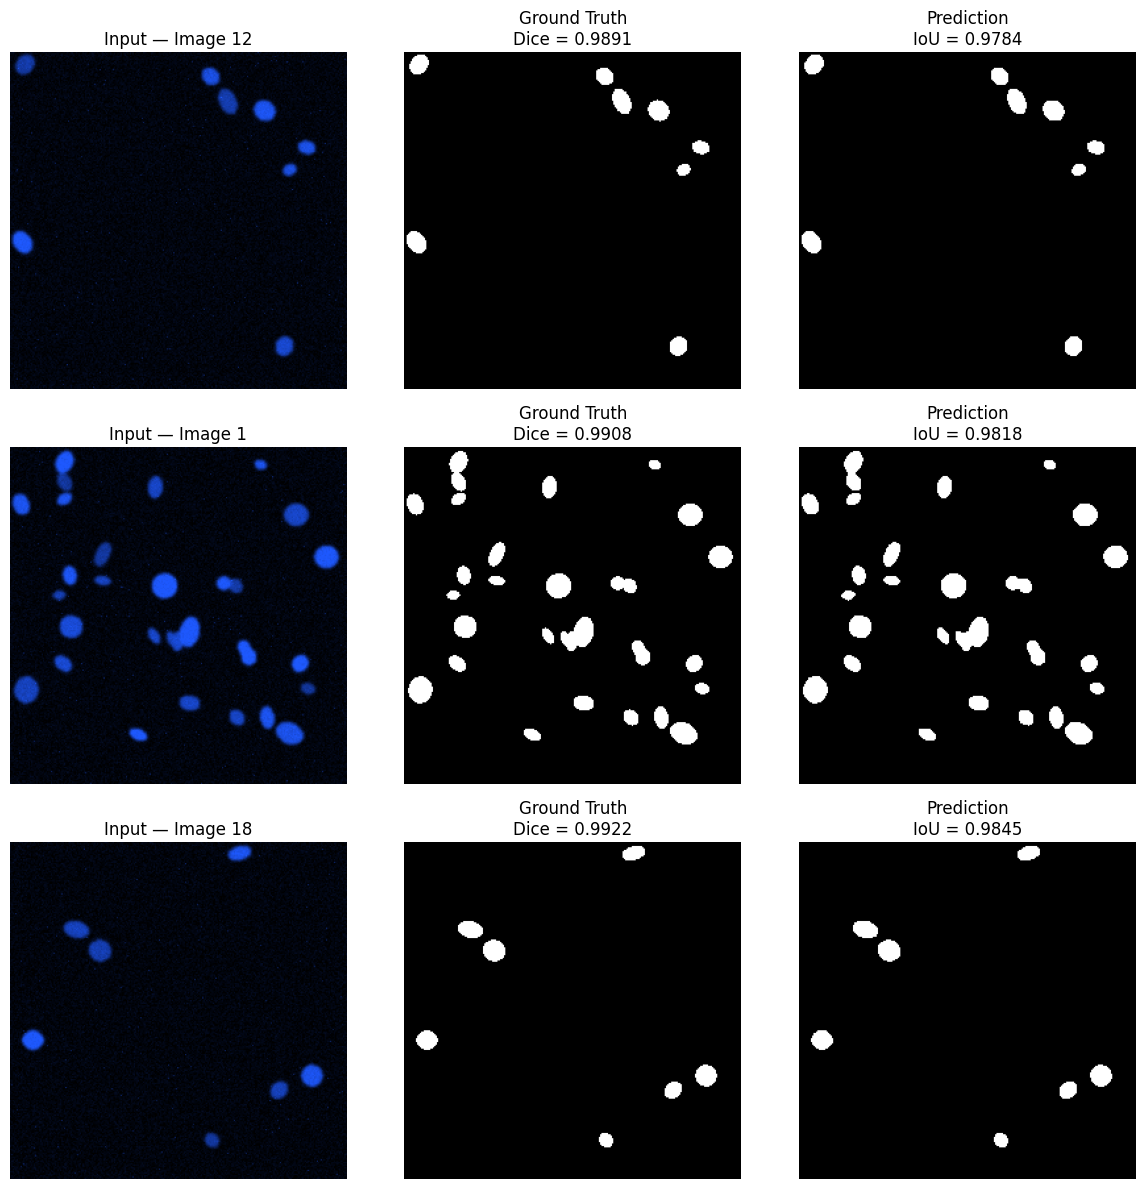

Worst-case figure saved to:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_evaluation_worst_cases.png


In [23]:
# ============================================================
# 11. Visualise three lowest-Dice cases
# ============================================================

worst_three = (
    worst_cases
    .head(3)
    ["image_index"]
    .tolist()
)


fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)


for row, idx in enumerate(
    worst_three
):

    image, mask = val_dataset[idx]

    probability, prediction = get_prediction(
        model,
        image,
        device,
        THRESHOLD
    )

    image_np = (
        image
        .permute(1, 2, 0)
        .numpy()
    )

    mask_np = (
        mask
        .squeeze()
        .numpy()
    )


    row_metrics = metrics_df[
        metrics_df["image_index"] == idx
    ].iloc[0]


    # Input
    axes[row, 0].imshow(
        image_np
    )

    axes[row, 0].set_title(
        f"Input — Image {idx}"
    )

    axes[row, 0].axis("off")


    # Ground truth
    axes[row, 1].imshow(
        mask_np,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"Ground Truth\n"
        f"Dice = {row_metrics['dice']:.4f}"
    )

    axes[row, 1].axis("off")


    # Prediction
    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 2].set_title(
        f"Prediction\n"
        f"IoU = {row_metrics['iou']:.4f}"
    )

    axes[row, 2].axis("off")


plt.tight_layout()


worst_cases_path = os.path.join(
    OUTPUT_FIG_DIR,
    "unet_evaluation_worst_cases.png"
)


plt.savefig(
    worst_cases_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Worst-case figure saved to:"
)

print(worst_cases_path)

## 6. Evaluation summary

The U-Net achieved very high segmentation performance on the held-out validation set.

The mean Dice and IoU values indicate that predicted foreground regions overlap closely with the annotated nuclei masks. Precision and recall provide additional evidence about false-positive and false-negative segmentation pixels.

The per-image analysis is retained alongside the mean scores because aggregate metrics alone do not show where residual errors occur.

The validation results should not be interpreted as evidence of clinical readiness. The dataset is a small experimental segmentation dataset, and the evaluation therefore measures performance within this dataset rather than generalisation to unseen clinical populations or imaging protocols.

In [24]:
# ============================================================
# 12. Report-ready evaluation summary
# ============================================================

print()
print("=" * 70)
print("REPORT-READY U-NET EVALUATION SUMMARY")
print("=" * 70)

print(
    f"Validation images evaluated : {len(val_dataset)}"
)

print(
    f"Decision threshold          : {THRESHOLD}"
)

print(
    f"Mean Dice                   : {mean_dice:.4f}"
)

print(
    f"Mean IoU                    : {mean_iou:.4f}"
)

print(
    f"Mean Precision              : {mean_precision:.4f}"
)

print(
    f"Mean Recall                 : {mean_recall:.4f}"
)

print(
    f"Lowest Dice                 : "
    f"{metrics_df['dice'].min():.4f}"
)

print(
    f"Highest Dice                : "
    f"{metrics_df['dice'].max():.4f}"
)

print("=" * 70)

print("\nSaved outputs:")
print(
    "• unet_validation_metrics.csv"
)
print(
    "• unet_validation_summary.csv"
)
print(
    "• unet_evaluation_representative.png"
)
print(
    "• unet_evaluation_worst_cases.png"
)


REPORT-READY U-NET EVALUATION SUMMARY
Validation images evaluated : 20
Decision threshold          : 0.5
Mean Dice                   : 0.9948
Mean IoU                    : 0.9897
Mean Precision              : 0.9915
Mean Recall                 : 0.9982
Lowest Dice                 : 0.9891
Highest Dice                : 0.9979

Saved outputs:
• unet_validation_metrics.csv
• unet_validation_summary.csv
• unet_evaluation_representative.png
• unet_evaluation_worst_cases.png


## 7. Conclusion

The trained U-Net provides highly accurate segmentation on the held-out validation split, with strong Dice, IoU, precision, and recall scores.

Visual inspection confirms that the model reproduces the annotated nuclei regions closely in representative examples. The lowest-performing validation cases are also examined separately to identify residual segmentation errors rather than relying solely on the aggregate metrics.

The results support using the U-Net as the segmentation component of the subsequent hybrid pipeline. However, the high validation performance should be interpreted within the limits of the small dataset. It does not establish robustness across different scanners, staining conditions, imaging modalities, laboratories, or clinical populations.

The next stage uses the segmentation output for classical region-based feature extraction and structured LLM interpretation.